In [1]:
import collections
import glob
import hydra
import matplotlib.pyplot as plt
import numpy as np
import torch
import wandb
from omegaconf import DictConfig, OmegaConf
from solo.args.pretrain import parse_cfg
from solo.methods.ta import BYOLWithTA
from hydra import compose, initialize
from solo.losses.byol import byol_loss_func

from pytorch_lightning import seed_everything

from solo.methods import METHODS

from solo.data.pretrain_dataloader import (
    FullTransformPipeline,
    NCropAugmentation,
    build_transform_pipeline,
    prepare_dataloader,
    prepare_datasets,
)

import torch.nn.functional as F

/home/adondera/projects/manifold-ta/venv/lib/python3.9/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:35: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/adondera/projects/manifold-ta/venv/lib/python3.9/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:93: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  contrast

In [2]:
%matplotlib inline

In [3]:
run_ID = "zty0cgo5"

assert len(glob.glob(f"trained_models/byol-ta/{run_ID}/*.ckpt")) == 1, "There's more than one checkpoint"
checkpoint_path = glob.glob(f"trained_models/byol-ta/{run_ID}/*.ckpt")[0]

In [6]:
wandb.run.finish()

epoch,13
lr-AdamW/backbone,0.0002
lr-AdamW/classifier,0.0002
lr-AdamW/key_matrix,0.0002
lr-AdamW/predictor,0.0002
lr-AdamW/projector,0.0002
lr-AdamW/query_matrix,0.0002
lr-AdamW/value_matrix,0.0002
tau,0.99
train_acc1_epoch,12.6873
train_acc1_step,12.5


In [7]:
with initialize(version_base=None, config_path="scripts/pretrain/cifar"):
    cfg = compose(config_name="byol-ta.yaml")

OmegaConf.set_struct(cfg, False)
cfg = parse_cfg(cfg)
seed_everything(cfg.seed)
model = METHODS[cfg.method](cfg)

# Load a pretrained model
path = "trained_models/byol-ta/zty0cgo5/byol-ta-cifar10-both-branch-bn-adamw-256batch-zty0cgo5-ep=12.ckpt"
weights = torch.load(checkpoint_path)
model.load_state_dict(weights['state_dict'])
model.eval()

Global seed set to 5


BYOLWithTA(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        

In [8]:
pipelines = []
for aug_cfg in cfg.augmentations:
    pipelines.append(
        NCropAugmentation(
            build_transform_pipeline(cfg.data.dataset, aug_cfg), aug_cfg.num_crops
        )
    )
transform = FullTransformPipeline(pipelines)

if cfg.debug_augmentations:
    print("Transforms:")
    print(transform)

train_dataset = prepare_datasets(
    cfg.data.dataset,
    transform,
    train_data_path=cfg.data.train_path,
    data_format=cfg.data.format,
    no_labels=cfg.data.no_labels,
    data_fraction=cfg.data.fraction,
)
train_loader = prepare_dataloader(
    train_dataset, batch_size=cfg.optimizer.batch_size, num_workers=cfg.data.num_workers
)

Files already downloaded and verified


In [9]:
# Each element returned by the iterator is of the following form:
# indices, list of size num_crops - each elem containing batch size images, indices
train_loader_iterator = iter(train_loader)

In [10]:
img_batch = next(train_loader_iterator)
with torch.no_grad():
    model_inputs = img_batch[1][0]
output = model(model_inputs)

In [11]:
def normalized_std(representation):
    with torch.no_grad():
        z_std = (
            F.normalize(representation, dim=-1)
            .std(dim=1)
            .mean()
        )
    return z_std


def attention_weights(model, batch):
    out = super(type(model), model).training_step(batch, 0)
    results = collections.defaultdict(list)
    neg_cos_sim = 0
    for idx1 in range(model.num_large_crops):
            for idx2 in np.delete(range(model.num_crops), idx1):
                z = model.projector(out["feats"][idx1])
                results['backbone_student'].append(out['feats'][idx1].detach())
                results['projector_student'].append(z.detach())

                with torch.no_grad():
                    momentum_z = model.momentum_projector(out["momentum_feats"][idx2])
                results['backbone_teacher'].append(out["momentum_feats"][idx2])
                results['projector_teacher'].append(momentum_z)

                student_queries = model.query_matrix(z)
                student_keys = model.key_matrix(z)
                student_values = model.value_matrix(z)
                
                results['student_queries'].append(student_queries.detach())
                results['student_keys'].append(student_keys.detach())
                results['student_values'].append(student_values.detach())

                with torch.no_grad():
                    teacher_queries = model.momentum_query_matrix(momentum_z)
                    teacher_keys = model.momentum_key_matrix(momentum_z)
                    teacher_values = model.momentum_value_matrix(momentum_z)

                results['teacher_queries'].append(teacher_queries.detach())
                results['teacher_keys'].append(teacher_keys.detach())
                results['teacher_values'].append(teacher_values.detach())
                    
                key_pool = (
                    torch.cat([student_keys, teacher_keys.detach()])
                    .transpose(0, 1)
                    .contiguous()
                )
                value_pool = torch.cat([student_values, teacher_values.detach()])

                d = student_queries.shape[-1]
                student_weights = torch.nn.functional.softmax(
                    torch.mm(student_queries, key_pool) / np.sqrt(d),
                    dim=-1,
                )
                
                results['student_weights'].append(student_weights.detach())

                student_y = torch.mm(student_weights, value_pool)
                
                results['ta_student'].append(student_y.detach())
                
                p = model.predictor(student_y)

                with torch.no_grad():
                    teacher_weights = torch.nn.functional.softmax(
                        torch.mm(teacher_queries, key_pool) / np.sqrt(d),
                        dim=-1,
                    )
                    
                    teacher_y = torch.mm(teacher_weights, value_pool)

                results['teacher_weights'].append(teacher_weights.detach())
                results['ta_teacher'].append(teacher_y.detach())

                neg_cos_sim += byol_loss_func(p, teacher_y)

    return results, neg_cos_sim

In [12]:
with torch.no_grad():
    results, loss = attention_weights(model, img_batch)

/home/adondera/projects/manifold-ta/venv/lib/python3.9/site-packages/pytorch_lightning/core/module.py:377: UserWarning: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`
  rank_zero_warn(


Student output normalized std: 0.030189555138349533
Student output unnormalized std: 0.31088167428970337


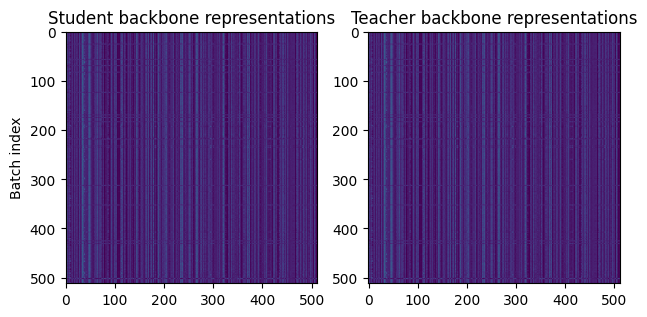

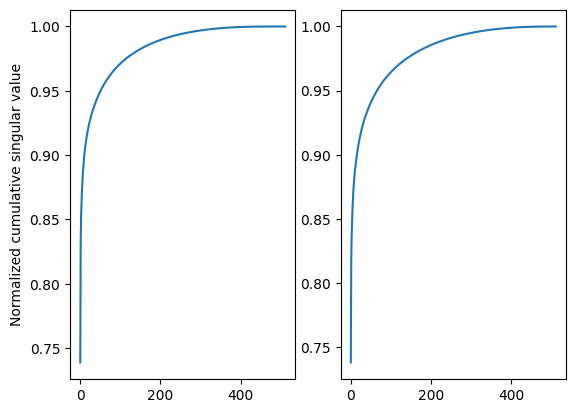

In [13]:
student_repr = torch.cat(results['backbone_student'])
teacher_repr = torch.cat(results['backbone_teacher'][::-1])

# Show representations for encoder / momentum encoder
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.title.set_text("Student backbone representations")
ax1.set_ylabel("Batch index")
ax1.imshow(F.normalize(student_repr))
ax2.title.set_text("Teacher backbone representations")
ax2.imshow(F.normalize(student_repr))
plt.tight_layout()

# Show rank / eigenvalue cumsum plut

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(torch.cumsum(F.normalize(torch.linalg.svdvals(student_repr), dim=0, p=1.0), dim=0))
ax1.set_ylabel("Normalized cumulative singular value")
ax2.plot(torch.cumsum(F.normalize(torch.linalg.svdvals(teacher_repr), dim=0, p=1.0), dim=0))

# Print mean / standard deviation
# print(f"Mean normalized vector: {F.normalize(torch.cat(results['backbone_student']), dim=-1).mean(dim=0)}")
print(f"Student output normalized std: {normalized_std(student_repr)}")
print(f"Student output unnormalized std: {student_repr.std(dim=-1).mean()}")

Student output normalized std: 0.06232785806059837
Student output unnormalized std: 2.907623291015625


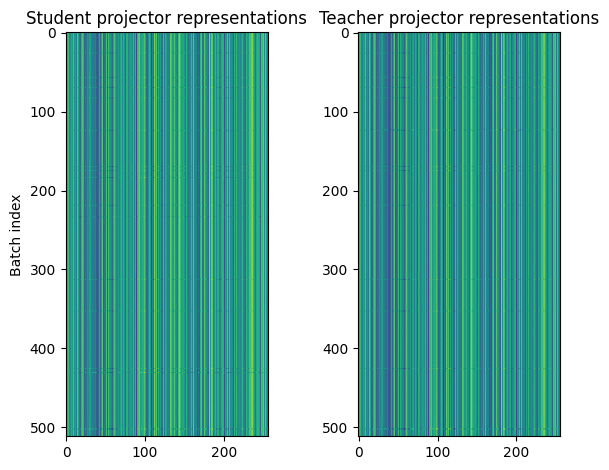

In [14]:
student_projector = torch.cat(results['projector_student'])
teacher_projector = torch.cat(results['projector_teacher'][::-1])

# Show representations for encoder / momentum encoder
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.title.set_text("Student projector representations")
ax1.set_ylabel("Batch index")
ax1.imshow(F.normalize(student_projector))
ax2.title.set_text("Teacher projector representations")
ax2.imshow(F.normalize(teacher_projector))
plt.tight_layout()

# Print mean / standard deviation
# print(f"Mean normalized vector: {F.normalize(torch.cat(results['backbone_student']), dim=-1).mean(dim=0)}")
print(f"Student output normalized std: {normalized_std(student_projector)}")
print(f"Student output unnormalized std: {student_projector.std(dim=-1).mean()}")

Student output normalized std: 0.06260522454977036
Student output unnormalized std: 19.348194122314453


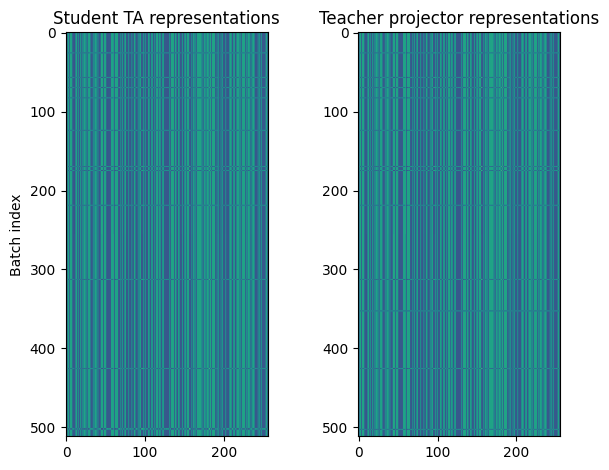

In [15]:
student_ta = torch.cat(results['ta_student'])
teacher_ta = torch.cat(results['ta_teacher'][::-1])

# Show representations for encoder / momentum encoder
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.title.set_text("Student TA representations")
ax1.set_ylabel("Batch index")
ax1.imshow(F.normalize(student_ta))
ax2.title.set_text("Teacher projector representations")
ax2.imshow(F.normalize(teacher_ta))
plt.tight_layout()

# Print mean / standard deviation
# print(f"Mean normalized vector: {F.normalize(torch.cat(results['backbone_student']), dim=-1).mean(dim=0)}")
print(f"Student output normalized std: {normalized_std(student_ta)}")
print(f"Student output unnormalized std: {student_ta.std(dim=-1).mean()}")

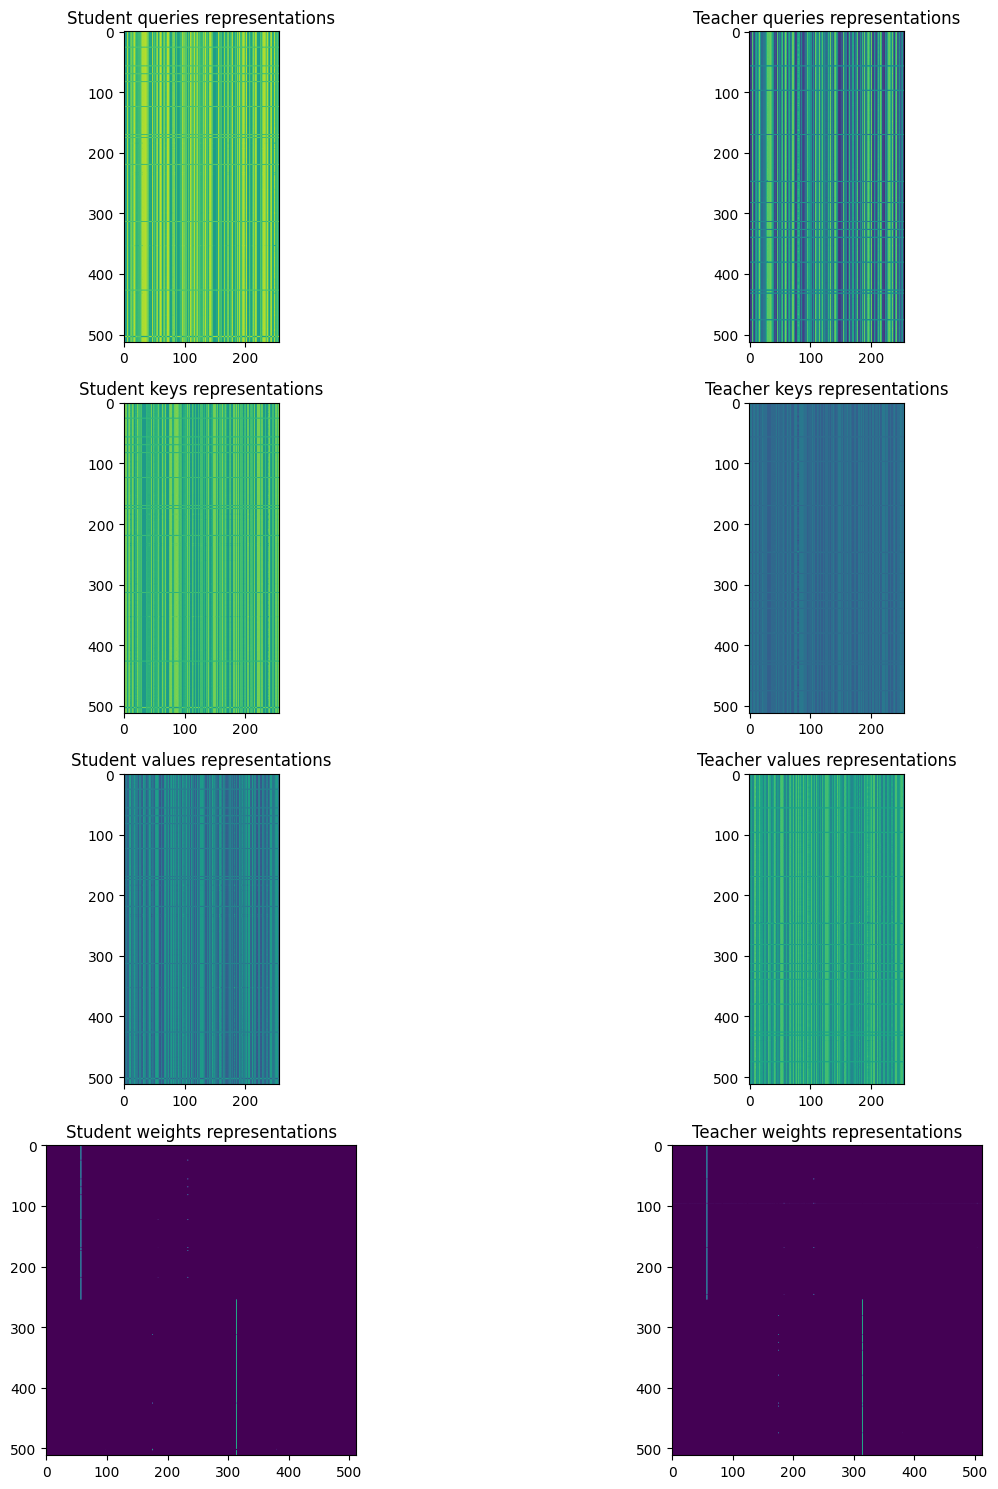

In [16]:
fig, ax = plt.subplots(4, 2, figsize=(15,15))
for idx, name in enumerate(["queries", "keys", "values", "weights"]):
    ax[idx][0].title.set_text(f"Student {name} representations")
    ax[idx][0].imshow(F.normalize(torch.cat(results[f'student_{name}']), dim=-1))
    ax[idx][1].title.set_text(f"Teacher {name} representations")
    ax[idx][1].imshow(F.normalize(torch.cat(results[f'teacher_{name}']), dim=-1))

plt.tight_layout()

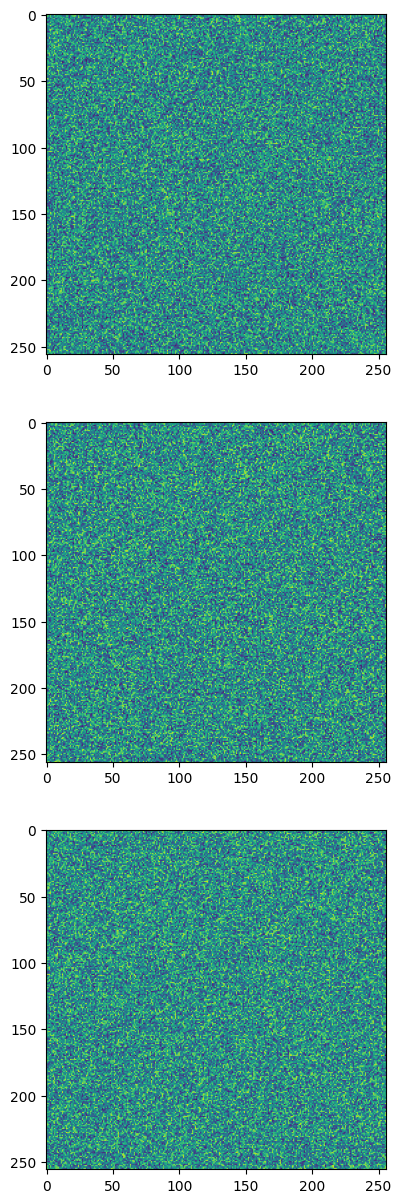

In [25]:
fig, ax = plt.subplots(3,1, figsize=(15,15))

ax[0].imshow(model.query_matrix[0].weight.detach())
ax[1].imshow(model.key_matrix[0].weight.detach())
ax[2].imshow(model.value_matrix[0].weight.detach())

In [ ]:
# TODO: Analyze the representations of combinations of student and queries. What happens after multiplication for example.

# student_queries = model.query_matrix(proj_features[0])
# student_keys = model.key_matrix(proj_features[0])
# student_values = model.value_matrix(proj_features[0])

# teacher_queries = model.momentum_query_matrix(proj_features[1])
# teacher_keys = model.momentum_key_matrix(proj_features[1])
# teacher_values = model.momentum_value_matrix(proj_features[1])

# d = student_queries.shape[-1]

# ax.imshow((torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d)).detach().numpy())
# fig
# print((torch.mm(student_queries, student_keys.transpose(0,1)) / 16)[0, 245])
# print((torch.mm(student_queries, student_keys.transpose(0,1)) / 16)[0, 17])
# print(F.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1)[0, 245])
# print(F.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1)[0, 17])
# torch.topk(torch.mm(student_queries, student_keys.transpose(0,1)) / 16, 2, dim=-1)
# torch.topk(F.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1), 2, dim=-1)
# ax.imshow(F.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1).detach().numpy())
# fig
# torch.argmax(torch.mm(student_queries, student_keys.transpose(0,1)), dim=-1)

In [27]:
run = wandb.init(id=run_ID, project="solo-learn", resume="must", save_code=True)
run.finish()

epoch,13
lr-AdamW/backbone,0.0002
lr-AdamW/classifier,0.0002
lr-AdamW/key_matrix,0.0002
lr-AdamW/predictor,0.0002
lr-AdamW/projector,0.0002
lr-AdamW/query_matrix,0.0002
lr-AdamW/value_matrix,0.0002
tau,0.99
train_acc1_epoch,12.6873
train_acc1_step,12.5
